In [1]:
!pip install pingouin
!pip install statsmodels
!pip install researchpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pylab


from scipy.stats import (
    fisher_exact, levene, bartlett, fligner,
    pearsonr, spearmanr, kendalltau, ttest_ind, norm,
    f, chi2_contingency
)


from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler,MinMaxScaler,RobustScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.power import tt_ind_solve_power, TTestIndPower
from statsmodels.tools.tools import add_constant
from statsmodels.stats.contingency_tables import mcnemar, cochrans_q


import pingouin as pg
import researchpy as rp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.3 MB/s eta 0:00:00


In [2]:
data=pd.read_csv("Wdata.csv")
data['Date/Time']=pd.to_datetime(data['Date/Time'])
data.head(10000)

data.rename(columns={'Rel Hum_%': 'Rel_Hum'}, inplace=True)
print("Размер данных:",data.shape)
data.drop(columns=['Weather']).mean()

Размер данных: (8784, 8)


,0
Date/Time,2012-07-01 23:30:00
Temp_C,8.798144
Dew Point Temp_C,2.555294
Rel_Hum,67.431694
Wind Speed_km/h,14.945469
Visibility_km,27.664447
Press_kPa,101.051623


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date/Time         8784 non-null   datetime64[ns]
 1   Temp_C            8784 non-null   float64       
 2   Dew Point Temp_C  8784 non-null   float64       
 3   Rel_Hum           8784 non-null   int64         
 4   Wind Speed_km/h   8784 non-null   int64         
 5   Visibility_km     8784 non-null   float64       
 6   Press_kPa         8784 non-null   float64       
 7   Weather           8784 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 549.1+ KB


# Пункт1:

In [22]:
alpha=np.array([0.01,0.05,0.1])
SData1=data.Press_kPa.values[:data.shape[0]//2]
SData2=data.Press_kPa.values[data.shape[0]//2:]

SData1 = np.random.normal(loc=1, scale=10, size=1000)
SData2 = np.random.normal(loc=3, scale=10, size=1000)

#SData=data.Press_kPa.values


In [23]:
#критерий стьюдента предполагает нормальность и равенство дисперсий
#проверяет различия в средних значениях
t_stat, p_value_two = ttest_ind(SData1, SData2,equal_var=False)
t_stat, p_value_g = ttest_ind(SData1, SData2, alternative='greater')
t_stat, p_value_l = ttest_ind(SData1, SData2, alternative='less')
print(f'P-Значения:\nДвусторонний:{p_value_two}\nПравосторонний:{p_value_g}\nЛевосторонний:{p_value_l}\nПо уровням значимости:\n' )
n1=SData1.size
n2=SData2.size
print(n1,n2)

effect_size=(SData1.mean()-SData2.mean())/np.sqrt(((n1-1)*np.var(SData1)+(n2-1)*np.var(SData2))/(n1+n2-2))
ratio=n2/n1

for a in alpha:

  print(f"  Alpha = {a}")
  t_stat, p_value_two = ttest_ind(SData1, SData2,equal_var=False)
  print(f"Двусторонний: t={t_stat:.3f}, p={p_value_two:.4f}, Отвергнуть H0: {p_value_two < a}")
  print(f"Правосторонний (mu1 > mu2): Отвергнуть H0: {p_value_g < a}")
  print(f"Левосторонний (mu1 < mu2): Отвергнуть H0: {p_value_l < a}")

  print(f"Оценка мощности критерия:\n")
  # Создание объекта для анализа мощности
  power_analysis = TTestIndPower()

# Расчет мощности для разных альтернатив
  power_two_sided = power_analysis.solve_power(
      effect_size=effect_size,
      nobs1=n1,
      ratio=ratio,
      alpha=a,
      power=None,
      alternative='two-sided'
  )

  power_greater = power_analysis.solve_power(
      effect_size=effect_size,
      nobs1=n1,
      ratio=ratio,
      alpha=a,
      power=None,
      alternative='larger'
  )
  power_less = power_analysis.solve_power(
      effect_size=effect_size,
      nobs1=n1,
      ratio=ratio,
      alpha=a,
      power=None,
      alternative='smaller'
  )


  print(f"Мощность двустороннего критерия: {power_two_sided:.3f}")
  print(f"Мощность правостороннего критерия: {power_greater:.3f}")
  print(f"Мощность левостороннего критерия: {power_less:.3f}")
  required_n = power_analysis.solve_power(
    effect_size=effect_size,      # размер эффекта (Cohen's d)
    nobs1=None,          # то, что мы ищем ✅
    alpha=a,          # уровень значимости
    power=0.8,           # желаемая мощность
    ratio=ratio,             # соотношение групп
    alternative='smaller'
  )
  print(f"желаемый объем выборок для заданной мощности левостороннего критерия: {required_n}")
  print('-'*50)
print(f"Текущий объем выборки:{n1}")


P-Значения:
Двусторонний:0.0009778418674892188
Правосторонний:0.9995110855856335
Левосторонний:0.0004889144143664675
По уровням значимости:

1000 1000
  Alpha = 0.01
Двусторонний: t=-3.302, p=0.0010, Отвергнуть H0: True
Правосторонний (mu1 > mu2): Отвергнуть H0: False
Левосторонний (mu1 < mu2): Отвергнуть H0: True
Оценка мощности критерия:

Мощность двустороннего критерия: 0.766
Мощность правостороннего критерия: 0.000
Мощность левостороннего критерия: 0.835
желаемый объем выборок для заданной мощности левостороннего критерия: 921.0488932961221
--------------------------------------------------
  Alpha = 0.05
Двусторонний: t=-3.302, p=0.0010, Отвергнуть H0: True
Правосторонний (mu1 > mu2): Отвергнуть H0: False
Левосторонний (mu1 < mu2): Отвергнуть H0: True
Оценка мощности критерия:

Мощность двустороннего критерия: 0.910
Мощность правостороннего критерия: 0.000
Мощность левостороннего критерия: 0.951
желаемый объем выборок для заданной мощности левостороннего критерия: 567.242868117813

In [24]:
# ранговый Критерий Уилкоксона-Манна-Уитни проверяет схожесть распределений, используя порядковые номера элементов
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
stat_two, p_two = stats.mannwhitneyu(SData1, SData2, alternative='two-sided')
stat_greater, p_greater = stats.mannwhitneyu(SData1, SData2, alternative='greater')
stat_less, p_less = stats.mannwhitneyu(SData1, SData2, alternative='less')
print(f'P-Значения:\nДвусторонний:{p_two}\nПравосторонний:{p_greater}\nЛевосторонний:{p_less}\nПо уровням значимости:\n' )
results = []
for a in alpha:
    alpha1 = 1 - a
    print(f"(Alpha = {a})")
    print(f"Двусторонний: Отвергнуть H₀: {p_two < a}")
    print(f"Пправосторонний (>): Отвергнуть H₀: {p_greater < a}")
    print(f"Левосторонний (<): Отвергнуть H₀: {p_less < a}")
    print('-'*50)

P-Значения:
Двусторонний:0.0036992088650247544
Правосторонний:0.9981508528401911
Левосторонний:0.0018496044325123772
По уровням значимости:

(Alpha = 0.01)
Двусторонний: Отвергнуть H₀: True
Пправосторонний (>): Отвергнуть H₀: False
Левосторонний (<): Отвергнуть H₀: True
--------------------------------------------------
(Alpha = 0.05)
Двусторонний: Отвергнуть H₀: True
Пправосторонний (>): Отвергнуть H₀: False
Левосторонний (<): Отвергнуть H₀: True
--------------------------------------------------
(Alpha = 0.1)
Двусторонний: Отвергнуть H₀: True
Пправосторонний (>): Отвергнуть H₀: False
Левосторонний (<): Отвергнуть H₀: True
--------------------------------------------------


In [25]:
print("уровни значимости: [0.01, 0.05, 0.1]")

df1 = len(SData1) - 1
df2 = len(SData2) - 1
f_stat = np.var(SData1, ddof=1) / np.var(SData2, ddof=1)
p_value = 2 * min(f.cdf(f_stat, df1, df2), 1 - f.cdf(f_stat, df1, df2))
print("Тест Фишера")
print(f"p-value={p_value:.3f}")
print("Дисперсии равны с опред. уровнем значимости:",alpha<p_value)
print('-'*50)

#не требует гормальности
stat, p_value = levene(SData1, SData2)
print("Тест Левена")
print(f"p-value={p_value:.3f}")
print("Дисперсии равны с опред. уровнем значимости:",alpha<p_value)
print('-'*50)

stat, p_value = bartlett(SData1, SData2)
print("Тест Бартлета")
print(f"p-value={p_value:.3f}")
print("Дисперсии равны с опред. уровнем значимости:",alpha<p_value)
print('-'*50)

#не требует гормальности
stat, p_value = fligner(SData1, SData2)
print("Тест Флингера")
print(f"p-value={p_value:.3f}")
print("Дисперсии равны с опред. уровнем значимости:",alpha<p_value)
print('-'*50)



уровни значимости: [0.01, 0.05, 0.1]
Тест Фишера
p-value=0.382
Дисперсии равны с опред. уровнем значимости: [ True  True  True]
--------------------------------------------------
Тест Левена
p-value=0.220
Дисперсии равны с опред. уровнем значимости: [ True  True  True]
--------------------------------------------------
Тест Бартлета
p-value=0.382
Дисперсии равны с опред. уровнем значимости: [ True  True  True]
--------------------------------------------------
Тест Флингера
p-value=0.218
Дисперсии равны с опред. уровнем значимости: [ True  True  True]
--------------------------------------------------


#2. Исследование корреляций

In [8]:
'''
Коэффициенты корреляции Пирсона
Требования:

Нормальное распределение всех переменных
Отсутствие сильных выбросов
Корректно интерпретирует только линейные связи
'''
NData=data.drop(columns=["Weather","Date/Time"])

corr_matrix = NData.corr(method='pearson')
corr_matrix.head()

,Temp_C,Dew Point Temp_C,Rel_Hum,Wind Speed_km/h,Visibility_km,Press_kPa
Temp_C,1.000000,0.932714,-0.220182,-0.061876,0.273455,-0.236389
Dew Point Temp_C,0.932714,1.000000,0.139494,-0.095685,0.050813,-0.320616
Rel_Hum,-0.220182,0.139494,1.000000,-0.092743,-0.633683,-0.231424
Wind Speed_km/h,-0.061876,-0.095685,-0.092743,1.000000,0.004883,-0.356613
Visibility_km,0.273455,0.050813,-0.633683,0.004883,1.000000,0.231847


In [9]:
'''
Коэффициенты корреляции Спирмена
Требования:
корректно работает при монотонной связи в данных
не требует нормальности, отсутствия сильных выбросов и линейности
'''
corr_matrix = NData.corr(method='spearman')
corr_matrix.head()


,Temp_C,Dew Point Temp_C,Rel_Hum,Wind Speed_km/h,Visibility_km,Press_kPa
Temp_C,1.000000,0.924596,-0.228065,-0.048260,0.200615,-0.245195
Dew Point Temp_C,0.924596,1.000000,0.125921,-0.090413,-0.012333,-0.336143
Rel_Hum,-0.228065,0.125921,1.000000,-0.121486,-0.575643,-0.240836
Wind Speed_km/h,-0.048260,-0.090413,-0.121486,1.000000,-0.041660,-0.318607
Visibility_km,0.200615,-0.012333,-0.575643,-0.041660,1.000000,0.263279


In [10]:
'''
Коэффициенты корреляции Кендалла
Требования:
корректно работает при монотонной связи в данных
не требует нормальности, отсутствия сильных выбросов и линейности
'''
corr_matrix = NData.corr(method='kendall')
corr_matrix.head()

,Temp_C,Dew Point Temp_C,Rel_Hum,Wind Speed_km/h,Visibility_km,Press_kPa
Temp_C,1.000000,0.767642,-0.149638,-0.031318,0.150310,-0.164407
Dew Point Temp_C,0.767642,1.000000,0.086898,-0.061481,-0.008593,-0.229041
Rel_Hum,-0.149638,0.086898,1.000000,-0.084500,-0.450804,-0.162536
Wind Speed_km/h,-0.031318,-0.061481,-0.084500,1.000000,-0.031709,-0.224136
Visibility_km,0.150310,-0.008593,-0.450804,-0.031709,1.000000,0.195319


Заметна корреляция (Temp_C и Dew Point Temp_C)	и (Rel_Hum и Visibility_km), обе можно обосновать физически

# 3. Использование методов на таблице сопряженности:

In [26]:
#исследуем связь Weather ~ Temp_C, строим таблицу сопряженности
import warnings

warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

def my_func(x):
  if(x>10):
    return 2
  elif(x>0):
    return 1
  elif(x>-10):
    return -1
  else:
    return -2

MData=data[['Weather','Press_kPa','Temp_C']]

for i in range(MData.shape[0]):
  id=MData.iloc[i]
  d=id.Weather.split(',')
  MData.iloc[i,MData.columns.get_loc('Weather')]=d[0]
  for j in range(1,len(d)):
    jj=MData.iloc[i].copy(deep=True)
    jj.loc['Weather']=d[j]
    MData.loc[MData.shape[0]]=jj

MData1=MData.copy(deep=True)

ll={i:MData[MData.Weather==i]['Weather'].shape[0] for i in np.unique(MData.Weather.values)}
var=MData.Temp_C
MData.Temp_C= pd.Series([ my_func(var[i]) for i in range(var.size)])
var=MData.Weather
MData.Weather=pd.Series(['Others' if ll[var[i]]<100 else var[i] for i in range(var.size)])

columns=np.unique(MData.Weather)
index=[-1,-2,1,2]
varData=np.array([[MData[(MData.Weather==columns[i]) & (MData.Temp_C==index[j])].shape[0] for j in range(4)]for i in range(len(columns))]).T
SM=pd.DataFrame(varData,index=index,columns=columns)
SM.head()

,Clear,Cloudy,Drizzle,Fog,Mainly Clear,Mostly Cloudy,Others,Rain,Rain Showers,Snow
-1,289,326,1,67,296,302,135,1,0,339
-2,147,89,0,15,120,91,14,0,0,41
1,302,537,87,208,338,558,42,264,73,128
2,588,776,51,132,1352,1118,30,189,137,0


In [30]:

#ни одна частота не должна быть меньше 5 общее число измерений >20
#H0-не зависят
SM_hi=SM
chi2_stat, p_value, dof, expected = chi2_contingency(SM_hi)
print(f"Хи-квадрат: p-value связи между категориями Temp_C и Weather = {p_value}, статистика = {chi2_stat}")
#точный тест Фишера(более точная оценка p-value, таблица 2х2, большие вычисления на больших выборках)

odds_ratio, p_value = fisher_exact(SM_hi[['Cloudy','Clear']].iloc[[0,1]], alternative='two-sided')
print(f"Точный тест Фишера: p-value связи между категориями Temp_C и Weather в подтаблице = {p_value}")

#тест МакНемара (в отличие от предыдущих тестов репрезентация работает на связанных данных)
#H0 - Вероятность изменения из состояния A в состояние B равна вероятности изменения из состояния B в состояние A
result = mcnemar(SM_hi[['Cloudy','Clear']].iloc[[1,2]].rename(columns={'Cloudy':0,'Clear':1}))
print(f"Точный тест МакНемара: p-value связи между категориями Temp_C и Weather в подтаблице = {result.pvalue}")
'Таким образом, данные зависимы в данных категориях'

Хи-квадрат: p-value связи между категориями Temp_C и Weather = 0.0, статистика = 2046.9401560894396
Точный тест Фишера: p-value связи между категориями Temp_C и Weather в подтаблице = 6.674047129155591e-05
Точный тест МакНемара: p-value связи между категориями Temp_C и Weather в подтаблице = 3.2311742677852644e-27


'Таким образом, данные зависимы в данных категориях'

# Пункт 4

In [13]:
#требование для нахождения фактора инфляции дисперсии: Ни одна переменная не должна быть линейной комбинацией других, Количество наблюдений должно превышать количество признаков
for i in range(len(NData.columns)):
  print(f"Для столбца {NData.columns[i]} VIF равен",variance_inflation_factor(NData.values, i))
corr_matrix = NData.corr(method='pearson')
corr_matrix.head()

Для столбца Temp_C VIF равен 301.34622457345245
Для столбца Dew Point Temp_C VIF равен 199.54538811248042
Для столбца Rel_Hum VIF равен 445.41426027601136
Для столбца Wind Speed_km/h VIF равен 3.995494085272676
Для столбца Visibility_km VIF равен 10.250562634333438
Для столбца Press_kPa VIF равен 794.3796882248004


,Temp_C,Dew Point Temp_C,Rel_Hum,Wind Speed_km/h,Visibility_km,Press_kPa
Temp_C,1.000000,0.932714,-0.220182,-0.061876,0.273455,-0.236389
Dew Point Temp_C,0.932714,1.000000,0.139494,-0.095685,0.050813,-0.320616
Rel_Hum,-0.220182,0.139494,1.000000,-0.092743,-0.633683,-0.231424
Wind Speed_km/h,-0.061876,-0.095685,-0.092743,1.000000,0.004883,-0.356613
Visibility_km,0.273455,0.050813,-0.633683,0.004883,1.000000,0.231847


Видно, что Press_kPa имеет достаточно высокий VIF, что говорит о его высокой степени мультиколлениарности

# Пункт 5

In [14]:
MData1.head()#Температура непрерывна

,Weather,Press_kPa,Temp_C
0,Fog,101.24,-1.8
1,Fog,101.24,-1.8
2,Freezing Drizzle,101.26,-1.8
3,Freezing Drizzle,101.27,-1.5
4,Fog,101.23,-1.5


In [15]:
MData.head()#Температура разбита на 4 категории

,Weather,Press_kPa,Temp_C
0,Fog,101.24,-1
1,Fog,101.24,-1
2,Others,101.26,-1
3,Others,101.27,-1
4,Fog,101.23,-1


In [16]:
#Требования: нормальность, равенство дисперсий, независимость набл
#Однофакторный дисперсный анализ требования: 3 или более группы, нормальность, равенство дисперсий

f_stat, p_value = stats.f_oneway(MData1[MData1.Weather=='Clear']['Temp_C'].values,MData1[MData1.Weather=='Mainly Clear']['Temp_C'].values,MData1[MData1.Weather=='Mostly Cloudy']['Temp_C'].values)
print(f"p-value для однофакторного ANOVA={p_value}")

#Для примера:
f_stat, p_value = stats.f_oneway(np.random.normal(loc=1, scale=5, size=1000),np.random.normal(loc=1, scale=5, size=1000),np.random.normal(loc=1, scale=5, size=1000))
print(f"p-value для однофакторного ANOVA в примере со сгенерированными значениями={p_value}")

#Двуфакторный анализ, температура непрерывна:
model = ols('Press_kPa ~ C(Weather) + Temp_C + C(Weather):Temp_C', data=MData1[MData1.Weather.isin(['Clear','Cloudy','Drizzle',	'Fog',		'Mostly Cloudy'])]).fit()
anova_results = anova_lm(model, typ=2) # typ=2 для последовательного ANOVA
print(anova_results)

#Двуфакторный анализ, температура дискретна:
model = ols('Press_kPa ~ C(Weather) + Temp_C + C(Weather):Temp_C', data=MData[MData.Weather.isin(['Clear','Cloudy','Drizzle',	'Fog',		'Mostly Cloudy'])]).fit()
anova_results = anova_lm(model, typ=2) # typ=2 для последовательного ANOVA
print(anova_results)

p-value для однофакторного ANOVA=4.814344194648583e-41
p-value для однофакторного ANOVA в примере со сгенерированными значениями=0.4772735611824669
                        sum_sq      df           F         PR(>F)
C(Weather)          462.082978     4.0  214.639483  9.236459e-172
Temp_C              367.723772     1.0  683.236943  2.631955e-142
C(Weather):Temp_C    27.976994     4.0   12.995431   1.552770e-10
Residual           3053.793714  5674.0         NaN            NaN
                        sum_sq      df           F         PR(>F)
C(Weather)          393.428336     4.0  185.919606  5.901604e-150
Temp_C              430.340983     1.0  813.452601  2.540091e-167
C(Weather):Temp_C    17.436210     4.0    8.239705   1.270414e-06
Residual           3001.717287  5674.0         NaN            NaN


p-value очень малы, следовательно, можно сделать вывод, что как тип погоды, так и температура сильно влияют на давление, а так же, тип погоды имеет влияние на температуру

# Пункт 6

Будем оценивать величину Press_kPa с помощю моделей регрессии:

Величина ошибки: 0.44540537203701974 стандартное отклонение ответов: 0.8525903054575802


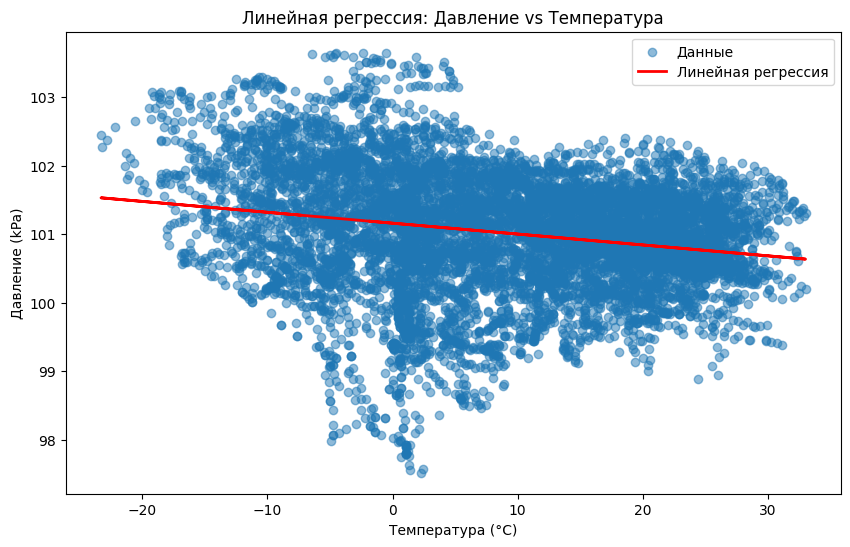

In [17]:
X = MData1[['Temp_C']]
y = MData1['Press_kPa']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)


y_pred = model_lr.predict(X_test)
print("Величина ошибки:",np.square(mean_squared_error(y_pred,y_test)),"стандартное отклонение ответов:",y.std())


plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Данные')
plt.plot(X, model_lr.predict(X), color='red', linewidth=2, label='Линейная регрессия')
plt.xlabel('Температура (°C)')
plt.ylabel('Давление (kPa)')
plt.legend()
plt.title('Линейная регрессия: Давление vs Температура')
plt.show()


Вывод: Линейная регрессия по одному параметру прогнозирует плохо, тк. многим значениям признака соответствует диапазон значений целевой переменной, следовательно, одним признаком при более точной регрессии не обойтись \
 Возьмем больше признаков, учитывая корелляцию некоторых, исключим признаки Dew Point Temp_C и Visibility_km \
 Используем регуляризаторы Ridge и Lasso

In [18]:
X = data[['Temp_C','Rel_Hum','Wind Speed_km/h']]
y = data['Press_kPa']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

model_lr = Ridge(alpha=1)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
print("Величина ошибки:",np.square(mean_squared_error(y_pred,y_test)),"стандартное отклонение ответов:",y.std())
print("Коэффициенты:",model_lr.coef_)

Величина ошибки: 0.24604021050984576 стандартное отклонение ответов: 0.8440047459486474
Коэффициенты: [-0.02403143 -0.01719652 -0.03960273]


In [19]:
X = data[['Temp_C','Rel_Hum','Wind Speed_km/h','Dew Point Temp_C', 'Visibility_km']]
y = data['Press_kPa']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

model_lr = Lasso(alpha=1)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
print("Величина ошибки:",np.square(mean_squared_error(y_pred,y_test)),"стандартное отклонение ответов:",y.std())
print("Коэффициенты:",model_lr.coef_)

Величина ошибки: 0.2457674447943299 стандартное отклонение ответов: 0.8440047459486474
Коэффициенты: [-0.         -0.00494725 -0.02465932 -0.01765774  0.00635201]


Как видно, lasso занулил коэффициент при Temp_C, которая скореллирована с Dew Point Temp_C \
Найдем оптимальные гиперпараметры для полиномиальной регрессии:

In [20]:
X = data[['Temp_C','Rel_Hum','Wind Speed_km/h']]
y = data['Press_kPa']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

param_grid = {
    'poly__degree': [1, 2, 3, 4, 5, 6],
    'poly__include_bias': [True, False],
    'scaler': [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler(),
        'passthrough'
    ]
}
poly_grid = GridSearchCV(
    poly_pipeline,
    param_grid,
    cv=2,
    scoring='r2',
    verbose=1
)
poly_grid.fit(X_train, y_train)
print("Лучшие параметры:", poly_grid.best_params_)
print("Лучший R2 на кросс-валидации:", poly_grid.best_score_)


Fitting 2 folds for each of 48 candidates, totalling 96 fits
Лучшие параметры: {'poly__degree': 5, 'poly__include_bias': True, 'scaler': 'passthrough'}
Лучший R2 на кросс-валидации: 0.332609533897699


Обучим модель с лучшими параметрами:

In [21]:

poly = PolynomialFeatures(degree=4,include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

model_lr = Ridge(alpha=1)
model_lr.fit(X_train_poly, y_train)

y_pred = model_lr.predict(X_test_poly)
print("Величина ошибки:",np.square(mean_squared_error(y_pred,y_test)),"стандартное отклонение ответов:",y.std())

Величина ошибки: 0.22611654634384123 стандартное отклонение ответов: 0.8440047459486474


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.87907e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Как видно, качество немного улучшилось